# Inner / Environment Contrast exploration

## Purpose

Here, I want to determine if a direct inner–environment color-mixture contrast carry genuine environmental information once the density-scaled subtraction is removed.

## Motivation

The submitted analysis treated the 12–20$R_e$ annulus as a local background and applied a density-scaled subtraction to the inner GC color-mixture diagnostic. The referee noted (point 2) and [permutation Null Test](03_spatial_pblue_null_test.ipynb) showed that this procedure introduces a strong environment-dependent null correlation because the subtraction amplitude depends directly on the annular GC counts.

The annular population itself also exhibits strong and coherent environmental trends, indicating that it is not an environmentally invariant nuisance background. This notebook therefore tests an alternative quantity: the direct contrast between the inner GC population and the surrounding 12–20$R_e$ population, without count- or area-dependent scaling,

$$ \Delta P_{\rm IE} = P_{\rm inner} - P_{\rm annulus}. $$

This quantity is interpreted as a host-centred versus local-environment contrast rather than as a background-corrected blue fraction. The primary goal is to determine, using the same permutation framework as the submitted analysis, whether any observed correlation with environment exceeds that expected from the analysis geometry alone.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Optional, Dict
from tqdm.auto import tqdm

import ast
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.stats import rayleightest
from scipy.stats import binomtest, ks_2samp, chi2, spearmanr,  pearsonr, linregress
from shapely.geometry import Polygon, Point
import logging

from src.config import (
    Columns,
    BCG,
    AnalysisConfig,
    ClusterCenter,
)

RNG_SEED = 20260830
rng = np.random.default_rng(RNG_SEED)

N_PERM = 1000   # development run

%load_ext autoreload
%autoreload 2

In [2]:
# logging function

def setup_logging(verbose=False, name = "Coma_GCs_debug"):
    """
    Call this once at the top of the notebook.
    If verbose=True, DEBUG messages will show; otherwise only INFO+.
    """    
    # Remove any root handlers (if I had root-level logging before)
    for h in logging.root.handlers[:]:
        logging.root.removeHandler(h)

    # Get named logger and clear *its* handlers + disable propagation
    logger = logging.getLogger(name)
    for h in logger.handlers[:]:
        logger.removeHandler(h)
    logger.propagate = False

    # Set logger’s level
    logger.setLevel(logging.DEBUG)   # we capture everything here

    # INFO-only handler (no timestamp)
    info_handler = logging.StreamHandler()
    info_handler.setLevel(logging.INFO)
    info_handler.addFilter(lambda rec: rec.levelno == logging.INFO)
    info_handler.setFormatter(logging.Formatter("%(message)s"))
    logger.addHandler(info_handler)

    # non-INFO handler (timestamped, DEBUG or WARNING+)
    other = logging.StreamHandler()
    other.setLevel(logging.DEBUG if verbose else logging.WARNING)
    other.addFilter(lambda rec: rec.levelno != logging.INFO)
    # allow only your logger’s DEBUG (if you still want a name-filter):
    other.addFilter(lambda rec: rec.levelno != logging.DEBUG or rec.name == name)
    fmt = "[%(levelname)s] %(asctime)s.%(msecs)03d %(message)s"
    other.setFormatter(logging.Formatter(fmt, datefmt="%H:%M:%S"))
    logger.addHandler(other)


In [3]:
# Set verbosity here:
name = "spatial_pblue_null"
setup_logging(verbose=True, name = name)   # or False

# testing logging
logger = logging.getLogger(name)
logger.debug("Debug messages are ON")
logger.info("Info messages are always shown")
logger.warning("Warnings also show up")


[DEBUG] 16:02:05.014 Debug messages are ON
Info messages are always shown
[WARNING] 16:02:05.016 Warnings also show up


# Initialization

## Load in galaxies

Load in a `csv` file, which has been produced from manual and online archives, and saved in `Coma_Gal_List_Create.ipynb`, so this can be used in the calculation and plotting routines.

A second file of more data from the SIMBAD and NED archives has bee extracted, but this has indeterminate or somewhat inconsistent effective radii.

Select using `archive = True` or `False` if "manual" data is preferred.


In [4]:
def prep_gal_shapes(gals_df: pd.DataFrame) -> pd.DataFrame:
    g = gals_df.copy()

    # Convert minor axis from arcmin -> arcsec when present
    # (Your 'galdim_minaxis' is arcmin per your note)
    g["minor_axis_arcsec"] = np.where(
        np.isfinite(g["galdim_minaxis"]),
        g["galdim_minaxis"].astype(float) * 60.0,
        np.nan
    )

    # Axis ratio q=b/a using available axes (ratio is robust to diameter vs semi-axis ambiguity)
    a = g["major_axis_arcsec"].astype(float)
    b = g["minor_axis_arcsec"].astype(float)

    q = b / a
    # Clip to sane range; if missing, default to circular
    g["q_axis"] = np.where(np.isfinite(q), np.clip(q, 0.2, 1.0), 1.0)

    # Clean PA; if missing, set 0 (ellipse aligned N-S; effect minimal for q~1)
    g["pa_deg"] = pd.to_numeric(g["galdim_angle"], errors="coerce").fillna(0.0)

    return g


In [5]:
archive = True
if archive:
    logger.warning('NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies - NOTE. With colors')
    # Load in the file of galaxy data extracted from archives OR 
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_from_archives.csv')
    gals_df_from_csv = gals_df.copy()
    gals_df = prep_gal_shapes(gals_df)
else:
    logger.warning('NOTE: Loading manual data for Coma cluster galaxies')
    # Load in the file of sanitised and augmented galaxy data  
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_cleaned.csv')
gals_df.tail(5)

[WARNING] 16:02:07.983 NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies - NOTE. With colors


,name,ra,dec,otype,z,Vmag_simbad_raw,Bmag_simbad_raw,BV_simbad_raw,gmag_simbad_raw,rmag_simbad_raw,...,Re_GCS_scale,Re_GCS_arcsec,n_gcs_prior,n_gcs_red_prior,n_gcs_blue_prior,gal_color,gal_color_src,minor_axis_arcsec,q_axis,pa_deg
169,NGC 4874,194.898789,27.959248,LIN,0.023910,12.71,13.7,0.990000,12.6472,11.7979,...,4.8,142.014382,NaN,NaN,NaN,1.254257,g-i,135.64440,0.966099,63.0
170,NGC 4869,194.847328,27.911592,EmG,0.022879,13.52,14.9,1.379999,14.4290,13.6240,...,3.2,23.865957,NaN,NaN,NaN,1.230054,g-i,41.45118,0.834300,47.0
171,NGC 4889,195.033738,27.977025,EmG,0.021500,11.30,13.0,1.700000,12.3528,11.5017,...,4.8,110.525917,NaN,NaN,NaN,1.033334,g-i,109.01400,0.621500,75.0
172,SDSS J130042.56+280658.6,195.177360,28.116320,LSB,0.020701,18.24,NaN,NaN,17.6480,17.0110,...,3.2,33.052243,NaN,NaN,NaN,0.868321,g-i,19.49800,1.000000,0.0
173,Coma cluster,195.017071,27.977025,CLUSTER,0.021500,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.0


In [6]:
# Test the load
gal1=['IC 4051','NGC 4883','NGC 4876']
for gal_i in gal1:
    gal_row = gals_df.loc[gals_df['name'] == gal_i].iloc[0]
    print(f"{gal_i}: mv={gal_row['mV_app']:4.2f} mag, MV={gal_row['MV_abs']:5.2f} mag")


IC 4051: mv=13.34 mag, MV=-21.66 mag
NGC 4883: mv=14.34 mag, MV=-20.66 mag
NGC 4876: mv=14.49 mag, MV=-20.51 mag


In [7]:
gals_df.columns

Index(['name', 'ra', 'dec', 'otype', 'z', 'Vmag_simbad_raw', 'Bmag_simbad_raw',
       'BV_simbad_raw', 'gmag_simbad_raw', 'rmag_simbad_raw',
       'imag_simbad_raw', 'zmag_simbad_raw', 'gr_simbad_raw', 'gi_simbad_raw',
       'major_axis_arcsec', 'galdim_minaxis', 'galdim_angle', 'dim_source',
       'galdim_qual', 'galdim_bibcode', 'dim_ref', 'MV_simbad_raw',
       'show_label', 'Re_arcsec', 'otype_family', 'morph_type', 'major_kpc',
       'is_large_E', 'sdss_objid', 'Re_r_arcsec', 'Re_r_arcsec_circ',
       'g_cmodel_sdss', 'r_cmodel_sdss', 'i_cmodel_sdss', 'gerr_cmodel_sdss',
       'rerr_cmodel_sdss', 'ierr_cmodel_sdss', 'Ag_sdss', 'Ar_sdss', 'Ai_sdss',
       'g0_cmodel_sdss', 'r0_cmodel_sdss', 'i0_cmodel_sdss', 'sdss_phot_ok',
       'gr0_sdss', 'gi0_sdss', 'g_model_sdss', 'r_model_sdss', 'i_model_sdss',
       'gerr_model_sdss', 'rerr_model_sdss', 'ierr_model_sdss',
       'g0_model_sdss', 'r0_model_sdss', 'i0_model_sdss', 'Vmag_sdss',
       'Vmag_sdss_err', 'V_source', 'mV

## Load CSS candidates

Now we have galaxy data, we need to load up the CSS candidate file. 

In [8]:
#inFileName = "allpointings_master.dat_NoOverlap"
# inFileName = "data/newallpointingsmaster_26may2021.dat"  # with delimeter ' '
inFileName = "data/inspectedpointings_merged_19Oct2024.csv"  # with delimieter ','

inFile = open(inFileName, 'r')
lines = inFile.readlines()
inFile.close

data = pd.read_csv(inFileName, delimiter=',')


and then we need to filter for color on CSS in general, and additional filter for UCDs on the tighter color range and luminosity, and outlined in paper 1. Color value are 

- CSS: *color* 0.5 < (F475W − F814W ) < 2.5 and 
- UCD: *color* 1.3 < (F475W − F814W ) < 2.1 and *magnitude* F814W < 22.9 mag


In [9]:
data = data[(data['color'] > 0.5) & (data['color'] < 2.5)]
data_bright = data.loc[data['mag_814']<=25.0].copy()  # take a cut of data where completeness is > ~90% 

# Define the range for UCD 'color' and 'mag_814'
ucd_color_min, ucd_color_max = 1.3, 2.1     #
ucd_mag_814_min, ucd_mag_814_max = 0, 22.9  # should be 0 mag to 22.9 mag

# remove duplicated data
data = data.drop_duplicates()

# Filter the DataFrame
gcs_df = data[(data['color'] <= ucd_color_min) | (data['color'] >= ucd_color_max) |
                 (data['mag_814'] <= ucd_mag_814_min) | (data['mag_814'] >= ucd_mag_814_max)]
ucd_df = data[(data['color'] > ucd_color_min) & (data['color'] < ucd_color_max) &
                 (data['mag_814'] > ucd_mag_814_min) & (data['mag_814'] < ucd_mag_814_max)]


In [10]:
total_gcs = len(gcs_df)
total_ucds = len(ucd_df)
total_css = len(data)
total_bright = len(data_bright)

print('Total GCs: ', total_gcs)
print('Total UCDs: ', total_ucds)
print('Total count: ', total_css)
print('Total bright (F814W ≤ 25.0 mag): ', total_bright)
print('Mag F814W min, max:', np.min(data['mag_814']), np.max(data['mag_814']) )
print('Mag F475W min, max:', np.min(data['mag_475']), np.max(data['mag_475']) )

data.head(5)

Total GCs:  22104
Total UCDs:  523
Total count:  22627
Total bright (F814W ≤ 25.0 mag):  10304
Mag F814W min, max: 16.66917944 29.0727298
Mag F475W min, max: 18.59635274 31.0122151


,x_wcs,y_wcs,flux_814,flux_475,mag_814,mag_475,color,pointing,x,y,type,x_wcs_f,y_wcs_f,gc_type_f,pointing_f,Unnamed: 15
0,194.09794,27.244074,0.458373,0.203884,26.152547,27.681062,1.528516,OS21,708.977,3994.384,gc,194.09794,27.244074,gc,OS21,NaN
1,194.09828,27.212645,1.207550,1.165456,25.100832,25.788280,0.687449,OS21,2964.827,4170.375,gc,194.09828,27.212645,gc,OS21,NaN
3,194.09916,27.222516,4.788598,2.630347,23.605074,24.904488,1.299414,OS21,2261.617,4052.017,gc,194.09916,27.222516,gc,OS21,NaN
4,194.09917,27.213105,4.268017,1.134324,23.730029,25.817677,2.087648,OS21,2937.748,4109.924,gc,194.09917,27.213105,gc,OS21,NaN
5,194.09971,27.207500,2.269763,2.564432,24.415643,24.932042,0.516399,OS21,3342.696,4111.336,gc,194.09971,27.207500,gc,OS21,NaN


In [11]:
data.columns

Index(['x_wcs', 'y_wcs', 'flux_814', 'flux_475', 'mag_814', 'mag_475', 'color',
       'pointing', 'x', 'y', 'type', 'x_wcs_f', 'y_wcs_f', 'gc_type_f',
       'pointing_f', 'Unnamed: 15'],
      dtype='str')

## Load and verify the metrics quantities

In [12]:
metrics_df = pd.read_csv(
    "../Coma_CSS_color/data/metrics_df_fiducial_orig_recal.csv"
)

PB_METRIC = "Delta_Pblue_mean_bgsub"
COLOR_METRIC = "Delta_mean_color_bgsub"

required = [
    "mean_color",
    "mean_color_bgsub",
    COLOR_METRIC,
    PB_METRIC,
]

for col in required:
    print(f"{col:30s}", col in metrics_df.columns)



mean_color                     True
mean_color_bgsub               True
Delta_mean_color_bgsub         True
Delta_Pblue_mean_bgsub         True


## Check environmental metrics and baseline


In [13]:
sub = metrics_df[
    ["Delta_Pblue_mean_bgsub",
     "gc_bg_voronoi_density_arcsec2_inv"]
].dropna()

rho_obs, p_obs = spearmanr(
    sub["Delta_Pblue_mean_bgsub"],
    sub["gc_bg_voronoi_density_arcsec2_inv"]
)

print(rho_obs, p_obs)

-0.4420041180507892 9.183121292985238e-06


In [14]:
RHO_OBS = rho_obs
P_OBS   = p_obs

# Add $P_\mathrm{blue}$ to CSS data

In [15]:
# import numpy as np
# from typing import Tuple, Optional, Callable

# def _normal_pdf(x: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
#     """Vectorized Normal PDF."""
#     x = np.asarray(x, dtype=float)
#     mu = np.asarray(mu, dtype=float)
#     sigma = np.asarray(sigma, dtype=float)
#     return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (np.sqrt(2.0 * np.pi) * sigma)

# # These were the submitted parameters for paper three, but I found an indexing error (see. Coma_Gal_Color_CMD.ipynb)
# #
#     # gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
#     #     (1.58, 0.30, 1.76, 0.19, 0.54),  # 23-24
#     #     (1.51, 0.15, 1.68, 0.23, 0.59),  # 24-25
#     #     (1.46, 0.18, 1.67, 0.25, 0.55),  # 25-26
#     #     (1.40, 0.22, 1.64, 0.28, 0.57),  # 26-27
#     # ),

# def compute_Pblue(
#     mag814: np.ndarray,
#     color: np.ndarray,
#     *,
#     bright_mag_cut: float = 23.0,
#     # mag-binned mixture model for >= bright_mag_cut
#     mag_edges: Tuple[float, ...] = (23.0, 24.0, 25.0, 26.0, 27.0),
#     # These are the 'recalibrated values'
#     gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
#         (1.521, 0.162, 1.707, 0.229, 0.56),  # 23-24
#         (1.457, 0.176, 1.668, 0.246, 0.58),  # 24-25
#         (1.399, 0.224, 1.641, 0.282, 0.57),  # 25-26
#         (1.217, 0.183, 1.596, 0.291, 0.45),  # 26-27
#     ),
#     # faint handling
#     faint_mode: str = "extend",   # "extend" or "clamp"
#     faint_max_edge: float = 28.0, # used only if extend
#     # optional prior modifier (later): fb(R) model
#     # If provided, pass an array fb of shape (N,) OR provide fb_func(r) separately.
#     fb: Optional[np.ndarray] = None,
# ) -> Tuple[np.ndarray, np.ndarray]:
#     """
#     Compute P(blue | color, mag) under a mag-binned 2-Gaussian mixture.

#     Returns:
#       Pblue (N,) float array
#       mag_bin_id (N,) int array (bright regime -> -1)
#     """
#     mag814 = np.asarray(mag814, dtype=float)
#     color = np.asarray(color, dtype=float)
#     if mag814.shape != color.shape:
#         raise ValueError("mag814 and color must have the same shape.")

#     N = mag814.size
#     Pblue = np.full(N, np.nan, dtype=float)
#     mag_bin_id = np.full(N, -1, dtype=int)

#     # Bright regime: undefined for bimodality by construction
#     bright = mag814 < bright_mag_cut
#     mid_or_faint = ~bright

#     # Prepare edges/params with faint handling
#     edges = np.asarray(mag_edges, dtype=float)
#     if faint_mode not in ("extend", "clamp"):
#         raise ValueError('faint_mode must be either "extend" or "clamp".')
#     params = np.array(gmm_params, dtype=float)
#     nbins = edges.size - 1
#     if params.shape[0] != nbins:
#         raise ValueError("gmm_params length must match len(mag_edges)-1.")

#     if faint_mode == "extend":
#         if faint_max_edge <= edges[-1]:
#             raise ValueError("faint_max_edge must be > mag_edges[-1] when extend.")
#         edges = np.concatenate([edges, [float(faint_max_edge)]])
#         params = np.vstack([params, params[-1:]])
#         nbins = edges.size - 1

#     if np.any(mid_or_faint):
#         m = mag814[mid_or_faint]
#         c = color[mid_or_faint]

#         bin_id = np.digitize(m, edges) - 1
#         bin_id = np.clip(bin_id, 0, nbins - 1)

#         mu_b = params[bin_id, 0]
#         sg_b = params[bin_id, 1]
#         mu_r = params[bin_id, 2]
#         sg_r = params[bin_id, 3]
#         w_b  = params[bin_id, 4]

#         # Likelihood terms
#         pb = w_b * _normal_pdf(c, mu_b, sg_b)
#         pr = (1.0 - w_b) * _normal_pdf(c, mu_r, sg_r)

#         # Optional prior modifier (later): replace w_b -> fb*w_b and (1-w_b)->(1-fb)*(1-w_b)?
#         # For now, if fb is provided, treat it as a multiplicative reweighting of the mixture prior:
#         if fb is not None:
#             fb_arr = np.asarray(fb, dtype=float)
#             if fb_arr.shape != mag814.shape:
#                 raise ValueError("fb must have the same shape as mag814/color if provided.")
#             fb_sub = fb_arr[mid_or_faint]
#             pb = fb_sub * pb
#             pr = (1.0 - fb_sub) * pr

#         denom = pb + pr
#         # Safe division
#         p = np.divide(pb, denom, out=np.full_like(pb, np.nan), where=denom > 0)

#         Pblue[mid_or_faint] = p
#         mag_bin_id[mid_or_faint] = bin_id

#     return Pblue, mag_bin_id


In [16]:
# Add in blue probability (based on magnitude and color of GCs)
# NOTE: The compute_Pblue function was originally below, but moved above as needs executing before 
# running this cell.

from src.color_metrics import compute_Pblue

Pblue_all, mag_bin_id = compute_Pblue(
    mag814=data["mag_814"].values,
    color=data["color"].values
)

data = data.copy()
data["Pblue"] = Pblue_all


## Check columns

In [27]:
keywords = [
    "inner",
    "annulus"
]

for keyword in keywords:
    matches = [
        c for c in metrics_df
        if keyword.lower() in c.lower()
    ]

    print(f"\n{keyword}:")
    print(matches)




inner:
['N_inner', 'N_inner_color', 'N_inner_Pblue', 'Pblue_mean_inner_raw', 'median_color_inner_raw', 'mean_color_inner_raw', 'sum_Pblue_inner', 'Pblue_std_inner', 'color_std_inner', 'Pblue_inner_meets_min']

annulus:
['N_annulus', 'N_annulus_color', 'N_annulus_Pblue', 'Pblue_mean_annulus', 'median_color_annulus', 'mean_color_annulus', 'sum_Pblue_annulus', 'Pblue_std_annulus', 'color_std_annulus', 'Pblue_annulus_nonzero']


# Build cut-down routines

In [18]:
perm_data = data.copy().reset_index(drop=True)
perm_data["_perm_idx"] = np.arange(len(perm_data), dtype=int)

pblue_orig = perm_data["Pblue"].to_numpy(dtype=float)

In [19]:

def select_gc_samples_for_galaxy(
    data,
    gal_row,
    cols,
    kRe_inner=8.0,
    kRe_outer=(12.0, 20.0),
):
    """
    Returns inner and annulus GC samples for one galaxy.
    """
    kRe = elliptical_radius_kRe(
        data[cols.gc_ra].values,
        data[cols.gc_dec].values,
        gal_row[cols.gal_ra],
        gal_row[cols.gal_dec],
        gal_row[cols.gal_Re_arcsec],
        gal_row["q_axis"],
        gal_row["pa_deg"],
    )

    data = data.copy()
    data["kRe"] = kRe

    inner = data[kRe <= kRe_inner]
    ann = data[(kRe > kRe_outer[0]) & (kRe <= kRe_outer[1])]

    return inner, ann

def elliptical_radius_kRe(
    gc_ra, gc_dec,
    gal_ra, gal_dec,
    Re_arcsec,
    q_axis,
    pa_deg,
):
    """
    Compute elliptical radius in units of Re for each GC relative to a galaxy.
    PA assumed East of North (SIMBAD convention).
    """
    # SkyCoord objects
    gc = SkyCoord(gc_ra * u.deg, gc_dec * u.deg)
    gal = SkyCoord(gal_ra * u.deg, gal_dec * u.deg)

    # Tangent-plane offsets (arcsec)
    dra = (gc.ra - gal.ra).to(u.arcsec).value * np.cos(gal.dec.to(u.rad).value)
    ddec = (gc.dec - gal.dec).to(u.arcsec).value

    # Rotate into galaxy frame
    pa = np.deg2rad(pa_deg)
    x =  dra * np.cos(pa) + ddec * np.sin(pa)
    y = -dra * np.sin(pa) + ddec * np.cos(pa)

    # Elliptical radius (arcsec)
    r_ell = np.sqrt(x**2 + (y / q_axis)**2)

    # Return in units of Re
    return r_ell / Re_arcsec

## Build the membership cache once

In [20]:
@dataclass
class Columns:
    # galaxy table columns
    gal_id: str = "name"
    gal_ra: str = "ra"
    gal_dec: str = "dec"
    gal_Re_arcsec: str = "Re_best_arcsec"
    gal_MV: str = "MV_abs"

    # GC table columns
    gc_ra: str = "x_wcs"
    gc_dec: str = "y_wcs"
    gc_color: str = "color"           # e.g., F475W-F814W
    gc_mag: Optional[str] = "mag_814"  # optional
    gc_host: Optional[str] = "gal_id"  # if we already have assignment

@dataclass
class AnalysisConfig:
    aperture_Re: float = 8.0
    # optional background annulus for "local GC density"
    bg_annulus_inner_Re: float = 12.0
    bg_annulus_outer_Re: float = 20.0

    # bootstrap
    n_boot: int = 300
    min_gc_for_gmm: int = 30  # below this, we can fall back to median-only
    min_gc_for_Pblue: int = 10
    # baseline fit
    huber_eps: float = 1.35   # robust regression tuning


In [21]:
galaxy_cache = {}

cols = Columns
cfg = AnalysisConfig

for _, gal in tqdm(
    gals_df.iterrows(),
    total=len(gals_df),
    desc="Caching aperture membership"
):
    inner, ann = select_gc_samples_for_galaxy(
        perm_data,
        gal,
        cols,
        kRe_inner=cfg.aperture_Re,
        kRe_outer=(
            cfg.bg_annulus_inner_Re,
            cfg.bg_annulus_outer_Re,
        ),
    )

    # Use EXACTLY the same eligibility mask as the current
    # Pblue calculation in compute_metrics_for_galaxy.
    inner_mask = np.isfinite(inner["color"].to_numpy(dtype=float)) & np.isfinite(inner["Pblue"].to_numpy(dtype=float))
    ann_mask = np.isfinite(ann["color"].to_numpy(dtype=float)) & np.isfinite(ann["Pblue"].to_numpy(dtype=float))

    inner_idx = inner.loc[inner_mask, "_perm_idx"].to_numpy(dtype=int)
    ann_idx   = ann.loc[ann_mask, "_perm_idx"].to_numpy(dtype=int)

    gal_id = gal[cols.gal_id]

    galaxy_cache[gal_id] = {
        "inner_idx": inner_idx,
        "ann_idx": ann_idx,
    }  


Caching aperture membership:   0%|          | 0/174 [00:00<?, ?it/s]

## Pull fixed baseline metrics

In [31]:
metrics_df["Delta_P_IE"] = (
    metrics_df["Pblue_mean_inner_raw"]
    - metrics_df["Pblue_mean_annulus"]
)

fixed_metrics = (
    metrics_df
    .set_index(cols.gal_id)
)


In [32]:
science_ids = fixed_metrics.index[
    np.isfinite(fixed_metrics["Delta_Pblue_mean_bgsub"])
]
len(science_ids)

93

In [33]:
fixed_metrics["r_bg"] = (
    fixed_metrics["alpha_eff"]
    * fixed_metrics["N_annulus_Pblue"]
    / fixed_metrics["N_inner_Pblue"]
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_69323/3521669378.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fixed_metrics["r_bg"] = (


## Build/test unshuffled fast reconstruction

Before permutations, we should test only the background-subtracted values

In [38]:
from src.color_metrics import background_correct_scalar, bootstrap_Pblue_mean

rows = []

for gal_id in science_ids:

    cache = galaxy_cache[gal_id]

    inner_idx = cache["inner_idx"]
    ann_idx   = cache["ann_idx"]

    inner_p = pblue_orig[inner_idx]
    ann_p   = pblue_orig[ann_idx]

    n_in_p = len(inner_p)
    n_bg_p = len(ann_p)

    # Exact central statistic used in submitted pipeline
    p_med, _ = bootstrap_Pblue_mean(
        inner_p,
        cfg.n_boot,
        seed=0,
    )

    inner_mean = float(np.mean(inner_p))
    ann_mean = float(np.mean(ann_p))

    # new inner environment contrast quantity added here
    delta_p_ie = inner_mean - ann_mean

    # Use the same effective areas as the original calculation - NOT USED WITH THIS TEST
    # area_inner = fixed_metrics.loc[gal_id, "A_ap_eff"]
    # area_ann   = fixed_metrics.loc[gal_id, "A_bg_eff"]

    rows.append({
        cols.gal_id: gal_id,
        "Pblue_mean_fast": inner_mean,
        "Pblue_ann_fast": ann_mean,
        "Delta_P_IE_fast": delta_p_ie,
    })

fast_df = (
    pd.DataFrame(rows)
    .set_index(cols.gal_id)
)

and test this against the saved values, which we have to calculate from the original values...

In [39]:

checks = pd.DataFrame({
    "mean_diff": (
        fast_df["Pblue_mean_fast"]
        - fixed_metrics.loc[science_ids, "Pblue_mean"]
    ),
    "ann_diff": (
        fast_df["Pblue_ann_fast"]
        - fixed_metrics.loc[science_ids, "Pblue_mean_annulus"]
    ),
    "p_ie_diff": (
        fast_df["Delta_P_IE_fast"]
        - fixed_metrics.loc[science_ids, "Delta_P_IE"]
    ),
})

print(checks.abs().describe())

       mean_diff      ann_diff     p_ie_diff
count  93.000000  9.300000e+01  9.300000e+01
mean    0.002407  5.968941e-19  5.968941e-18
std     0.002539  5.756238e-18  1.728956e-17
min     0.000065  0.000000e+00  0.000000e+00
25%     0.000687  0.000000e+00  0.000000e+00
50%     0.001326  0.000000e+00  0.000000e+00
75%     0.003578  0.000000e+00  0.000000e+00
max     0.011057  5.551115e-17  5.551115e-17


Check for differences...

In [40]:
check_df = pd.DataFrame({
    "inner_orig": fixed_metrics["Pblue_mean_inner_raw"],
    "inner_fast": fast_df["Pblue_mean_fast"],
    "ann_orig": fixed_metrics["Pblue_mean_annulus"],
    "ann_fast": fast_df["Pblue_ann_fast"],
})

check_df["Delta_IE_orig_direct"] = (
    check_df["inner_orig"]
    - check_df["ann_orig"]
)

check_df["Delta_IE_fast_direct"] = (
    check_df["inner_fast"]
    - check_df["ann_fast"]
)

check_df["Delta_diff"] = (
    check_df["Delta_IE_fast_direct"]
    - check_df["Delta_IE_orig_direct"]
)

print(
    check_df[
        [
            "inner_orig",
            "inner_fast",
            "ann_orig",
            "ann_fast",
            "Delta_IE_orig_direct",
            "Delta_IE_fast_direct",
            "Delta_diff",
        ]
    ].head(20).to_string()
)

print()
print(check_df["Delta_diff"].describe())

                         inner_orig  inner_fast  ann_orig  ann_fast  Delta_IE_orig_direct  Delta_IE_fast_direct    Delta_diff
name                                                                                                                         
2MASS J12594779+2805520         NaN         NaN       NaN       NaN                   NaN                   NaN           NaN
2MASS J13001763+2759145    0.743857         NaN  0.425547       NaN              0.318310                   NaN           NaN
2MASX J12590459+2754389         NaN         NaN       NaN       NaN                   NaN                   NaN           NaN
2MASX J12592016+2753098    0.582092         NaN  0.588258       NaN             -0.006166                   NaN           NaN
2MASX J12592022+2804278         NaN         NaN  0.685717       NaN                   NaN                   NaN           NaN
2MASX J12592136+2758248    0.501448         NaN  0.633654       NaN             -0.132206                   NaN       

## Fast-path validated

The cached aperture/annulus implementation reproduces the galaxy-level
statistics from the full recalibrated pipeline to machine precision.

Maximum absolute differences:

- inner mean $P_{\rm blue}$ mean: $5.6\times10^{-17}$
- annular mean $P_{\rm blue}$: $5.6\times10^{-17}$
- ie_diff $P_{\rm blue}$: $5.6\times10^{-17}$

The fast implementation can therefore be used for the permutation
experiment without rerunning the full galaxy-metric pipeline.

# Assign (and check) $P_\mathrm{blue}$ `mag_bin_id`'s

In [41]:
from src.color_metrics import compute_Pblue

mag814 = perm_data[cols.gc_mag].to_numpy(dtype=float)
color  = perm_data[cols.gc_color].to_numpy(dtype=float)

pblue_check, mag_bin_id = compute_Pblue(
    mag814,
    color,
)

In [42]:
mask = np.isfinite(pblue_orig) & np.isfinite(pblue_check)

diff = np.abs(
    pblue_orig[mask] - pblue_check[mask]
)

print(f"N compared = {mask.sum()}")
print(f"max |ΔPblue| = {diff.max():.3e}")

print(
    "NaN pattern identical:",
    np.array_equal(
        np.isnan(pblue_orig),
        np.isnan(pblue_check)
    )
)


N compared = 21834
max |ΔPblue| = 0.000e+00
NaN pattern identical: True


In [43]:
finite = np.isfinite(pblue_orig)

for b in np.unique(mag_bin_id[finite]):

    m = finite & (mag_bin_id == b)

    print(
        f"bin {b}: "
        f"N={m.sum():5d}, "
        f"mag={mag814[m].min():.3f}–{mag814[m].max():.3f}"
    )


bin 0: N= 2494, mag=23.001–24.000
bin 1: N= 7017, mag=24.000–25.000
bin 2: N= 9635, mag=25.000–26.000
bin 3: N= 2514, mag=26.000–26.998
bin 4: N=  174, mag=27.002–29.073


# Implement 1 permutation

## time the bootstrap helper

Gauge the time for the helper, so we can optimize if necessary


In [ ]:
import time

t0 = time.perf_counter()

for gal_id in science_ids:
    idx = galaxy_cache[gal_id]["inner_idx"]
    bootstrap_Pblue_mean(
        pblue_orig[idx],
        cfg.n_boot,
        seed=0,
    )

dt = time.perf_counter() - t0

print(f"93 galaxy bootstraps: {dt:.3f} s")
print(f"Estimated 1000 permutations: {dt*1000/60:.1f} min")


## Shuffle $P_{\rm blue}$ while preserving magnitude structure


In [44]:
def permute_pblue_within_mag_bins(
    pblue_orig,
    mag814,
    rng,
):
    """
    Permute finite Pblue values among spatial positions within
    magnitude strata.

    Bright objects with undefined Pblue remain undefined.
    """
    p = np.asarray(pblue_orig, dtype=float)
    mag = np.asarray(mag814, dtype=float)

    p_perm = p.copy()

    # Preserve the empirical magnitude dependence.
    bins = [
        (23.0, 24.0),
        (24.0, 25.0),
        (25.0, 26.0),
        (26.0, 27.0),
        (27.0, np.inf),
    ]

    assigned = np.zeros(len(p), dtype=bool)

    for lo, hi in bins:
        mask = (
            np.isfinite(p)
            & np.isfinite(mag)
            & (mag >= lo)
            & (mag < hi)
        )

        idx = np.flatnonzero(mask)

        if len(idx) > 1:
            p_perm[idx] = rng.permutation(p[idx])

        assigned[idx] = True

    # Fail loudly if some finite Pblue values weren't covered.
    unassigned = np.isfinite(p) & ~assigned

    if np.any(unassigned):
        vals = mag[unassigned]
        raise ValueError(
            f"{unassigned.sum()} finite Pblue values were not assigned "
            f"to a permutation bin. Magnitude range: "
            f"{np.nanmin(vals):.3f}–{np.nanmax(vals):.3f}"
        )

    return p_perm

In [45]:
def permute_pblue_within_gmm_bins(
    pblue,
    mag_bin_id,
    rng,
):
    pblue = np.asarray(pblue, dtype=float)
    mag_bin_id = np.asarray(mag_bin_id, dtype=int)

    p_perm = pblue.copy()

    finite = np.isfinite(pblue)

    for b in np.unique(mag_bin_id[finite]):

        idx = np.flatnonzero(
            finite & (mag_bin_id == b)
        )

        if len(idx) > 1:
            p_perm[idx] = rng.permutation(pblue[idx])

    return p_perm


## Pass any $P_{\rm blue}$ assignment through the fast galaxy calculation

In [55]:
def fast_metrics_for_assignment(
    pblue,
    galaxy_cache,
    science_ids,
    fixed_metrics,
    cfg,
):
    """
    Calculate galaxy-level Pblue metrics for one assignment.

    Returns
    -------
    p_inner_raw : ndarray
        Arithmetic mean Pblue in the inner aperture.

    p_annulus : ndarray
        Arithmetic mean Pblue in the background annulus.

    p_bgsub : ndarray
        Submitted background-corrected Pblue statistic, using the
        bootstrap central value for the inner aperture.
    """

    p_inner_values = []
    p_annulus_values = []
    diff_p_ie_values = []

    for gal_id in science_ids:

        cache = galaxy_cache[gal_id]

        inner_p = pblue[cache["inner_idx"]]
        ann_p   = pblue[cache["ann_idx"]]

        n_in = len(inner_p)
        n_bg = len(ann_p)

        # Raw inner diagnostic
        p_inner = float(np.mean(inner_p))

        # Annulus uses ordinary arithmetic mean
        p_annulus = float(np.mean(ann_p))
    
        # new inner environment contrast quantity added here
        delta_p_ie = p_inner - p_annulus  

        p_inner_values.append(p_inner)
        p_annulus_values.append(p_annulus)
        diff_p_ie_values.append(delta_p_ie)

    return (
        np.asarray(p_inner_values),
        np.asarray(p_annulus_values),
        np.asarray(diff_p_ie_values),
    )

## Refit the Huber relation and calculate the null statistic

In [47]:
from src.color_metrics import fit_baseline_huber

def evaluate_pblue_assignment(
    pblue,
    galaxy_cache,
    science_ids,
    fixed_metrics,
    cols,
    cfg,
    density_col="gc_bg_voronoi_density_arcsec2_inv",
):
    """
    Calculate four density correlations for one Pblue assignment:

      1. inner mean Pblue
      2. annulus mean Pblue
      3. direct inner-environment contrast
      4. MV-residualized inner-environment contrast
    """

    p_inner, p_annulus, p_ie = fast_metrics_for_assignment(
        pblue,
        galaxy_cache,
        science_ids,
        fixed_metrics,
        cfg,
    )

    MV = (
        fixed_metrics
        .loc[science_ids, cols.gal_MV]
        .to_numpy(dtype=float)
    )

    density = (
        fixed_metrics
        .loc[science_ids, density_col]
        .to_numpy(dtype=float)
    )

    # Refit MV baseline for this realization
    _, yhat = fit_baseline_huber(
        MV,
        p_ie,
        eps=cfg.huber_eps,
    )

    delta_ie = p_ie - yhat

    def get_spearman(y):
        ok = np.isfinite(y) & np.isfinite(density)

        rho, pval = spearmanr(
            y[ok],
            density[ok],
        )

        return rho, pval, int(ok.sum())

    rho_inner, p_inner_rho, n_inner = get_spearman(p_inner)
    rho_ann, p_ann_rho, n_ann = get_spearman(p_annulus)
    rho_inner_env, p_inner_env, n_inner_env = get_spearman(p_ie)
    rho_delta_ie, p_delta_ie, n_delta_ie = get_spearman(delta_ie)

    return {
        # Correlation statistics
        "rho_inner": rho_inner,
        "p_inner": p_inner_rho,
        "N_inner": n_inner,

        "rho_annulus": rho_ann,
        "p_annulus": p_ann_rho,
        "N_annulus": n_ann,

        "rho_inner_env": rho_inner_env,
        "p_inner_env": p_inner_env,
        "N_inner_env": n_inner_env,

        "rho_delta_ie": rho_delta_ie,
        "p_delta_ie": p_delta_ie,
        "N_delta_ie": n_delta_ie,

        # Galaxy-level arrays, useful for diagnostics
        "Pblue_mean_inner_raw": p_inner,
        "Pblue_mean_annulus": p_annulus,
        "Delta_P_IE": p_ie,
        "Delta_P_IE_resid": delta_ie,
    }


# First test - Unshuffled

In [56]:
test_orig = evaluate_pblue_assignment(
    pblue_orig,
    galaxy_cache,
    science_ids,
    fixed_metrics,
    cols,
    cfg,
)

for key in [
    "rho_inner",
    "rho_annulus",
    "rho_inner_env",
    "rho_delta_ie",
]:
    print(f"{key:12s}: {test_orig[key]:+.4f}")


rho_inner   : -0.2823
rho_annulus : -0.6167
rho_inner_env: +0.1972
rho_delta_ie: +0.2266


In [71]:
test_orig["rho_inner"]

np.float64(-0.2822953657008146)

# Test 2 - One shuffle

In [57]:
rng = np.random.default_rng(20260830)

mag814 = perm_data[cols.gc_mag].to_numpy(dtype=float)

pblue_perm = permute_pblue_within_mag_bins(
    pblue_orig,
    mag814,
    rng,
)

test_perm = evaluate_pblue_assignment(
    pblue_perm,
    galaxy_cache,
    science_ids,
    fixed_metrics,
    cols,
    cfg,
)

pairs = [
    ("Inner",          "rho_inner",     "p_inner"),
    ("Annulus",        "rho_annulus",   "p_annulus"),
    ("Inner Env",      "rho_inner_env", "p_inner_env"),
    ("Delta ie",       "rho_delta_ie",  "p_delta_ie"),
]

for label, rho_key, p_key in pairs:
    print(
        f"{label:15s}: "
        f"rho={test_perm[rho_key]:+.4f}  "
        f"p={test_perm[p_key]:.3g}"
    )


Inner          : rho=-0.1595  p=0.127
Annulus        : rho=-0.2618  p=0.0112
Inner Env      : rho=-0.0616  p=0.558
Delta ie       : rho=-0.0531  p=0.613


In [59]:
faint = (
    np.isfinite(pblue_orig)
    & np.isfinite(mag814)
    & (mag814 >= 28)
)

pd.DataFrame({
    "mag814": mag814[faint],
    "Pblue": pblue_orig[faint],
}).sort_values("mag814")

,mag814,Pblue
5,28.096572,0.840516
0,28.116236,0.005995
4,28.186531,0.742409
1,28.270369,0.724962
3,28.551979,0.839998
2,28.644614,0.711599
6,29.072730,0.001076


# One shuffle - test 2 (using recreated `mag_bin_id`'s)

In [58]:
rng = np.random.default_rng(20260830)

pblue_perm = permute_pblue_within_gmm_bins(
    pblue_orig,
    mag_bin_id,
    rng,
)

# Sanity checks
print(
    "Finite Pblue:",
    np.isfinite(pblue_orig).sum(),
    np.isfinite(pblue_perm).sum(),
)

print(
    "Multiset preserved:",
    np.allclose(
        np.sort(pblue_orig[np.isfinite(pblue_orig)]),
        np.sort(pblue_perm[np.isfinite(pblue_perm)]),
    )
)

test_perm = evaluate_pblue_assignment(
    pblue_perm,
    galaxy_cache,
    science_ids,
    fixed_metrics,
    cols,
    cfg,
)

pairs = [
    ("Inner",          "rho_inner",     "p_inner"),
    ("Annulus",        "rho_annulus",   "p_annulus"),
    ("Inner Env",      "rho_inner_env", "p_inner_env"),
    ("Delta ie",       "rho_delta_ie",  "p_delta_ie"),
]

for label, rho_key, p_key in pairs:
    print(
        f"{label:15s}: "
        f"rho={test_perm[rho_key]:+.4f}  "
        f"p={test_perm[p_key]:.3g}"
    )

Finite Pblue: 21834 21834
Multiset preserved: True
Inner          : rho=-0.1595  p=0.127
Annulus        : rho=-0.2618  p=0.0112
Inner Env      : rho=-0.0616  p=0.558
Delta ie       : rho=-0.0531  p=0.613


# Test 3 - development ensemble of 10

In [60]:
pairs = [
    ("Inner",     "rho_inner"),
    ("Annulus",   "rho_annulus"),
    ("Inner Env", "rho_inner_env"),
    ("Delta ie",  "rho_delta_ie"),
]

rng = np.random.default_rng(20260830)

rows = []

for i in range(10):

    pblue_perm = permute_pblue_within_gmm_bins(
        pblue_orig,
        mag_bin_id,
        rng,
    )

    result = evaluate_pblue_assignment(
        pblue_perm,
        galaxy_cache,
        science_ids,
        fixed_metrics,
        cols,
        cfg,
    )

    rows.append({
        "iteration": i + 1,
        "rho_inner": result["rho_inner"],
        "rho_annulus": result["rho_annulus"],
        "rho_inner_env": result["rho_inner_env"],
        "rho_delta_ie": result["rho_delta_ie"],
    })

    print(
        f"{i+1:3d}: "
        + "  ".join(
            f"{label}={result[key]:+.4f}"
            for label, key in pairs
        )
    )

rho_perm_10 = pd.DataFrame(rows)

for col in [
    "rho_inner",
    "rho_annulus",
    "rho_inner_env",
    "rho_delta_ie",
]:
    vals = rho_perm_10[col]

    print(
        f"{col:12s}: "
        f"mean={vals.mean():+.4f}  "
        f"median={vals.median():+.4f}  "
        f"min={vals.min():+.4f}  "
        f"max={vals.max():+.4f}"
    )

  1: Inner=-0.1595  Annulus=-0.2618  Inner Env=-0.0616  Delta ie=-0.0531
  2: Inner=-0.1735  Annulus=-0.0427  Inner Env=-0.1560  Delta ie=-0.1515
  3: Inner=+0.1178  Annulus=-0.1015  Inner Env=+0.1748  Delta ie=+0.1760
  4: Inner=-0.0111  Annulus=-0.0089  Inner Env=+0.0529  Delta ie=+0.0624
  5: Inner=-0.2639  Annulus=+0.0477  Inner Env=-0.3198  Delta ie=-0.3187
  6: Inner=-0.2116  Annulus=-0.1285  Inner Env=-0.0555  Delta ie=-0.0497
  7: Inner=-0.1505  Annulus=+0.0784  Inner Env=-0.1875  Delta ie=-0.1838
  8: Inner=-0.0190  Annulus=-0.0328  Inner Env=+0.0408  Delta ie=+0.0390
  9: Inner=+0.0617  Annulus=-0.0896  Inner Env=+0.1353  Delta ie=+0.1430
 10: Inner=-0.0189  Annulus=-0.0760  Inner Env=+0.0929  Delta ie=+0.0894
rho_inner   : mean=-0.0829  median=-0.0848  min=-0.2639  max=+0.1178
rho_annulus : mean=-0.0616  median=-0.0593  min=-0.2618  max=+0.0784
rho_inner_env: mean=-0.0284  median=-0.0073  min=-0.3198  max=+0.1748
rho_delta_ie: mean=-0.0247  median=-0.0054  min=-0.3187  max=+

# Test 4 - 100 permutations

Include TQDM monitor

In [61]:
from tqdm.auto import tqdm

N_PERM = 100
rng = np.random.default_rng(20260830)

rows = []

for i in tqdm(range(N_PERM), desc="Permutations"):

    pblue_perm = permute_pblue_within_gmm_bins(
        pblue_orig,
        mag_bin_id,
        rng,
    )

    result = evaluate_pblue_assignment(
        pblue_perm,
        galaxy_cache,
        science_ids,
        fixed_metrics,
        cols,
        cfg,
    )

    rows.append({
        "iteration": i + 1,
        "rho_inner": result["rho_inner"],
        "rho_annulus": result["rho_annulus"],
        "rho_inner_env": result["rho_inner_env"],
        "rho_delta_ie": result["rho_delta_ie"],
    })
    
null_df = pd.DataFrame(rows)

for col in [
    "rho_inner",
    "rho_annulus",
    "rho_inner_env",
    "rho_delta_ie",
]:
    vals = null_df[col]

    print(
        f"{col:12s}: "
        f"mean={vals.mean():+.4f}  "
        f"median={vals.median():+.4f}  "
        f"std={vals.std():.4f}  "
        f"range={vals.min():+.4f} to {vals.max():+.4f}"
    )

Permutations:   0%|          | 0/100 [00:00<?, ?it/s]

rho_inner   : mean=-0.0831  median=-0.0730  std=0.0998  range=-0.3915 to +0.1178
rho_annulus : mean=-0.1235  median=-0.1184  std=0.1199  range=-0.4222 to +0.1512
rho_inner_env: mean=-0.0012  median=+0.0069  std=0.1088  range=-0.3198 to +0.2081
rho_delta_ie: mean=-0.0002  median=+0.0082  std=0.1083  range=-0.3187 to +0.2135


In [62]:
rho_null = null_df["rho_delta_ie"]

print(f"N perm       = {len(rho_null)}")
print(f"mean         = {np.mean(rho_null):+.4f}")
print(f"median       = {np.median(rho_null):+.4f}")
print(f"std          = {np.std(rho_null, ddof=1):.4f}")
print(f"16–84%       = {np.percentile(rho_null, [16,84])}")
print(f"2.5–97.5%    = {np.percentile(rho_null, [2.5,97.5])}")

n_extreme = np.sum(rho_null <= RHO_OBS)

p_emp = (n_extreme + 1) / (len(rho_null) + 1)

print(f"N <= observed = {n_extreme}")
print(f"Empirical p    = {p_emp:.4f}")


N perm       = 100
mean         = -0.0002
median       = +0.0082
std          = 0.1083
16–84%       = [-0.11536809  0.10625466]
2.5–97.5%    = [-0.20450971  0.18763354]
N <= observed = 0
Empirical p    = 0.0099


In [63]:
z_obs = (
    RHO_OBS - np.mean(rho_null)
) / np.std(rho_null, ddof=1)

print(f"Observed offset from null mean = {z_obs:+.2f} sigma")


Observed offset from null mean = -4.08 sigma


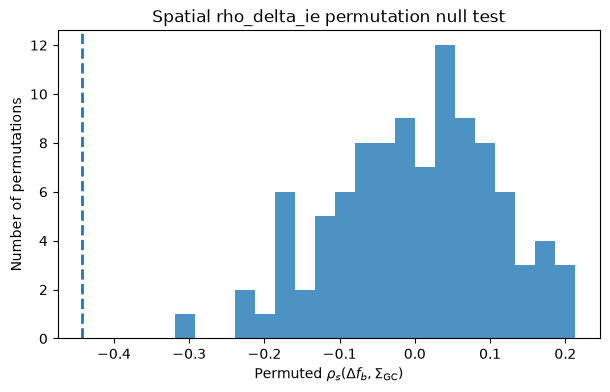

In [64]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(rho_null, bins=20, alpha=0.8)
ax.axvline(RHO_OBS, linestyle="--", linewidth=2)

ax.set_xlabel(r"Permuted $\rho_s(\Delta f_b,\Sigma_{\rm GC})$")
ax.set_ylabel("Number of permutations")
ax.set_title("Spatial rho_delta_ie permutation null test")

plt.show()


In [88]:
from tqdm.auto import tqdm

N_PERM = 10000
rng = np.random.default_rng(20260830)

rows = []

for i in tqdm(range(N_PERM), desc="Permutations"):

    pblue_perm = permute_pblue_within_gmm_bins(
        pblue_orig,
        mag_bin_id,
        rng,
    )

    result = evaluate_pblue_assignment(
        pblue_perm,
        galaxy_cache,
        science_ids,
        fixed_metrics,
        cols,
        cfg,
    )

    rows.append({
        "iteration": i + 1,
        "rho_inner": result["rho_inner"],
        "rho_annulus": result["rho_annulus"],
        "rho_inner_env": result["rho_inner_env"],
        "rho_delta_ie": result["rho_delta_ie"],
    })

null_df = pd.DataFrame(rows)

Permutations:   0%|          | 0/10000 [00:00<?, ?it/s]

In [89]:
summary = null_df[
    ["rho_inner", "rho_annulus", "rho_inner_env", "rho_delta_ie"]
].describe(
    percentiles=[0.025, 0.16, 0.5, 0.84, 0.975]
)

display(summary)


,rho_inner,rho_annulus,rho_inner_env,rho_delta_ie
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,-0.083135,-0.137886,0.009552,0.009839
std,0.104348,0.115939,0.102903,0.103240
min,-0.511459,-0.570589,-0.362374,-0.358255
2.5%,-0.285714,-0.357910,-0.192504,-0.192894
16%,-0.187110,-0.255738,-0.095145,-0.095271
50%,-0.083771,-0.139469,0.009624,0.010318
84%,0.021286,-0.020658,0.112844,0.113622
97.5%,0.122574,0.091015,0.209099,0.208219
max,0.332861,0.339053,0.387156,0.388559


In [79]:
obs = {
    "rho_inner":       test_orig["rho_inner"],
    "rho_annulus":     test_orig["rho_annulus"],
    "rho_inner_env":   test_orig["rho_inner_env"],
    "rho_delta_ie":    test_orig["rho_delta_ie"],
}
obs

{'rho_inner': np.float64(-0.2822953657008146),
 'rho_annulus': np.float64(-0.6166631852227626),
 'rho_inner_env': np.float64(0.1972188236698397),
 'rho_delta_ie': np.float64(0.2265524753066157)}

In [90]:
for col, rho_obs in obs.items():

    null = null_df[col].to_numpy()
    n = len(null)

    # Upper-tail probability: relevant because observed rho is positive
    p_upper = (
        np.sum(null >= rho_obs) + 1
    ) / (n + 1)

    # Two-sided empirical probability around the null mean
    null_mean = np.mean(null)

    p_two = (
        np.sum(
            np.abs(null - null_mean)
            >= np.abs(rho_obs - null_mean)
        ) + 1
    ) / (n + 1)

    z = (
        rho_obs - null_mean
    ) / np.std(null, ddof=1)

    print(
        f"{col:14s}  "
        f"obs={rho_obs:+.4f}  "
        f"null={null_mean:+.4f}  "
        f"z={z:+.2f}  "
        f"p_upper={p_upper:.4f}  "
        f"p_two={p_two:.4f}"
    )


rho_inner       obs=-0.2823  null=-0.0831  z=-1.91  p_upper=0.9726  p_two=0.0564
rho_annulus     obs=-0.6167  null=-0.1379  z=-4.13  p_upper=1.0000  p_two=0.0001
rho_inner_env   obs=+0.1972  null=+0.0096  z=+1.82  p_upper=0.0330  p_two=0.0680
rho_delta_ie    obs=+0.2266  null=+0.0098  z=+2.10  p_upper=0.0163  p_two=0.0345


In [91]:
null_df.to_csv(
    "data/intermediate/pblue_spatial_ie_permutation_10000.csv",
    index=False
)

Final results record

| Parameter | value |
|:---|:---:|
| seed | 20260830 |
| Nperm | 1000 |
| Ngal | 93 | 
| shuffle | Pblue within GMM magnitude bins |
| rho_obs | -0.4420041181 | 
| p_emp | 0.1439 |

## Current Assessment

GC color distributions vary strongly across the Coma core, including in the nominal local-background annuli. A weaker corresponding dependence exists within galaxy apertures. However, because the amplitude of the local-background subtraction is itself environmentally dependent, subtracting the 12–20 $R_e$ population and subsequently residualizing against host luminosity can generate much of the strong density dependence in the originally defined $\Delta f_b$ statistic.

# Permutation figure



/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_69323/743127328.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


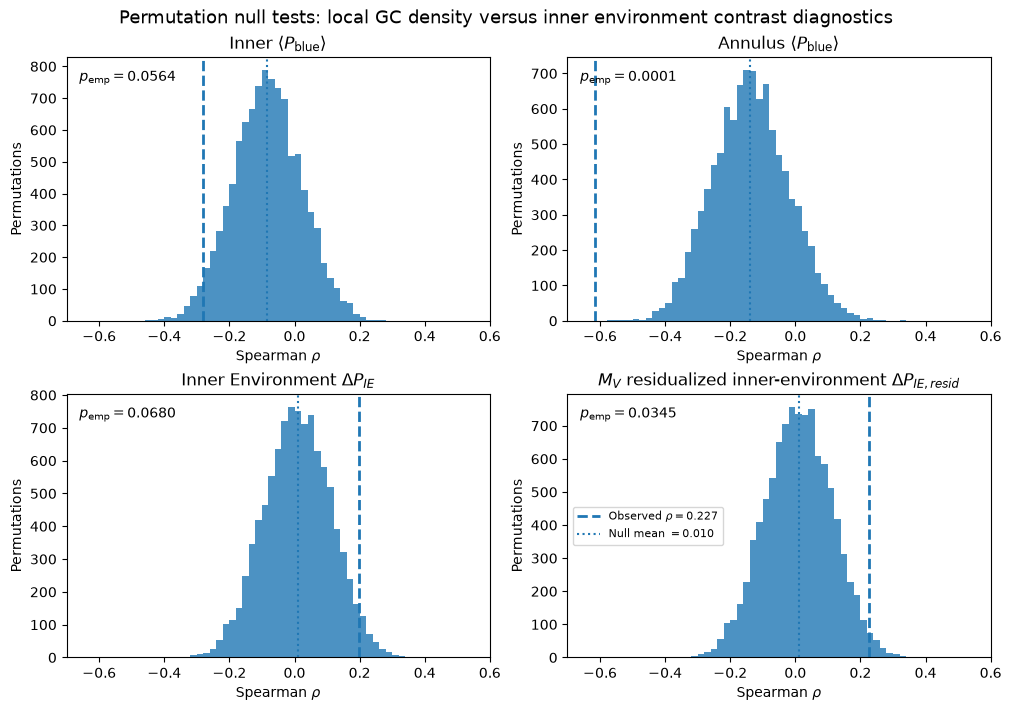

In [95]:
import matplotlib.pyplot as plt
import numpy as np

labels = {
    "rho_inner":   r"Inner $\langle P_{\rm blue}\rangle$",
    "rho_annulus": r"Annulus $\langle P_{\rm blue}\rangle$",
    "rho_inner_env":   r"Inner Environment $\Delta P_{IE}$",
    "rho_delta_ie":   r"$M_V$ residualized inner-environment $\Delta P_{IE, resid}$",
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

for ax, col in zip(axes.flat, obs):

    vals = null_df[col].to_numpy()
    rho_obs = obs[col]

    # n_extreme = np.sum(vals <= rho_obs)
    # p_emp = (n_extreme + 1) / (len(vals) + 1)


    

    # null = null_df[col].to_numpy()
    n = len(vals)

    # # Upper-tail probability: relevant because observed rho is positive
    # p_upper = (
    #     np.sum(vals >= rho_obs) + 1
    # ) / (n + 1)

    # Two-sided empirical probability around the null mean
    null_mean = np.mean(vals)

    p_two = (
        np.sum(
            np.abs(vals - null_mean)
            >= np.abs(rho_obs - null_mean)
        ) + 1
    ) / (n + 1)

    
    
    # ax.hist(vals, bins=30, alpha=0.8)
    bins = np.linspace(-0.6, 0.6, 61)
    ax.hist(vals, bins=bins, alpha=0.8)

    ax.axvline(
        rho_obs,
        linestyle="--",
        linewidth=2,
        label=fr"Observed $\rho={rho_obs:.3f}$"
    )

    ax.axvline(
        np.mean(vals),
        linestyle=":",
        linewidth=1.5,
        label=fr"Null mean $={np.mean(vals):.3f}$"
    )

    ax.set_title(labels[col])
    ax.set_xlabel(r"Spearman $\rho$")
    ax.set_ylabel("Permutations")

    ax.text(
        0.03, 0.95,
        fr"$p_{{\rm emp}}={p_two:.4f}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
    )
    xlim = (-0.7, 0.6)
    
    for ax in axes.flat:
        ax.set_xlim(xlim)

    ax.legend(fontsize=8)

fig.suptitle(
    r"Permutation null tests: local GC density versus inner environment contrast diagnostics",
    fontsize=13
)

plt.savefig('figures/intermediate/Perm_null_inner_env.png', bbox_inches='tight', format='png', dpi=200)

plt.show()

## Figure Interpretation

The purpose of this permutation null experiment has been to ask:

> If there were no real spatial connection between GC colour and environment, how strong a correlation would our analysis pipeline produce anyway?

Each histogram shows the distribution of Spearman correlations obtained from 10,000 shuffled realizations in which the GC $P_{\rm blue}$ values are randomized within magnitude bins while preserving the galaxy geometry, aperture membership, GC counts, local-density measurements, and other elements of the analysis. The dashed vertical line shows the correlation measured from the real data.

The four panels show a clear progression.

- For the inner GC population ($R<8R_e$), the observed correlation with local GC density is more negative than most shuffled realizations. The two-sided empirical probability is $p_{\rm emp}\simeq0.056$, so this is suggestive rather than formally strong evidence for an environmental dependence within the galaxy-centred apertures.
- For the 12–20$R_e$ annulus, the result is dramatically stronger. The observed correlation, $\rho\simeq-0.62$, lies beyond essentially the entire permutation distribution, with $p_{\rm emp}\simeq10^{-4}$. The surrounding GC population therefore contains a very strong environmental signal. This is the clearest result of the experiment and demonstrates that the annulus cannot be regarded as an environmentally invariant nuisance background.

- The direct inner–environment contrast,

$$ \Delta P_{\rm IE} = \langle P_{\rm blue}\rangle_{\rm inner} - \langle P_{\rm blue}\rangle_{\rm annulus}, $$

behaves very differently from the previously adopted density-scaled background subtraction. Its permutation null is centred close to zero, showing that the contrast itself does not mechanically generate a correlation with local GC density. The observed positive correlation ($\rho\simeq+0.20$) lies toward the upper tail of the null distribution, although the two-sided empirical probability ($p_{\rm emp}\simeq0.068$) remains only suggestive.

- After removing the dependence of the inner–environment contrast on galaxy luminosity, the observed correlation strengthens to $\rho\simeq+0.23$. The permutation null remains centred close to zero, while the observed value has $p_{\rm emp}\simeq0.035$. Thus the luminosity-residualized contrast shows modest evidence that galaxies in denser GC environments are relatively more blue-enhanced than their immediate surroundings.

The principal conclusion is therefore not that the GC populations contain no environmental information. Quite the opposite: the permutation experiment shows strong environmental structure, particularly in the nominal “background” annulus. The difficulty with the submitted analysis arose because this environmentally structured population was treated as a nuisance background and removed using a count- and area-scaled subtraction. That operation introduced a strong density-dependent correlation into the derived statistic.

Removing that scaling produces a much cleaner null distribution and changes the physical interpretation. Both the inner and surrounding GC populations become less blue with increasing local density, but the effect is considerably stronger in the surrounding 12–20$R_e$ population. Consequently, the galaxy-centred population becomes relatively blue-enhanced with respect to its immediate GC environment in the densest regions.

Working interpretation: the 12–20$R_e$ population should therefore be treated as an astrophysically structured local environment rather than as a simple background contaminant. The revised analysis should focus on the behaviour of the inner and surrounding GC populations separately, and on their direct contrast, rather than on the original density-scaled background-subtracted $\Delta f_b$ estimator.
